In [2]:
# import data
import pandas as pd
df = pd.read_csv('crime_aggregated.csv')
df.head()

,district,primary_type,hour,dow,month,n_incidents,arrest_rate,label_arrest_high
0,9,THEFT,11,7,12,41,0.073171,0
1,14,THEFT,13,6,2,41,0.097561,0
2,3,BATTERY,4,1,12,41,0.243902,0
3,7,NARCOTICS,20,7,2,41,1.000000,1
4,4,NARCOTICS,20,6,1,41,1.000000,1


In [3]:
df['arrest_rate'].unique()

array([0.07317073, 0.09756098, 0.24390244, ..., 0.7       , 0.6       ,
       0.65      ])

In [11]:
df['arrest_rate'].mean()

0.22605703714752545

In [12]:
df['arrest_rate'].median()

0.1372549019607843

### predict arrest (y) using light gbm model

### Threshold: 0.30 - high arrest probability

In [4]:
threshold = 0.30

df["arrest_high"] = (df["arrest_rate"] >= threshold).astype(int)

In [5]:
X = df[[
    "district",
    "primary_type",
    "hour",
    "dow",
    "month",
    "n_incidents"
]]

y = df["arrest_high"]

In [6]:
X = pd.get_dummies(X, columns=["primary_type"], drop_first=True)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 17330, number of negative: 89168
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 272
[LightGBM] [Info] Number of data points in the train set: 106498, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.162726 -> initscore=-1.638083
[LightGBM] [Info] Start training from score -1.638083


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [10]:
df

,district,primary_type,hour,dow,month,n_incidents,arrest_rate,label_arrest_high,arrest_high
0,9,THEFT,11,7,12,41,0.073171,0,0
1,14,THEFT,13,6,2,41,0.097561,0,0
2,3,BATTERY,4,1,12,41,0.243902,0,0
3,7,NARCOTICS,20,7,2,41,1.000000,1,1
4,4,NARCOTICS,20,6,1,41,1.000000,1,1
...,...,...,...,...,...,...,...,...,...
133118,8,THEFT,4,7,11,20,0.000000,0,0
133119,5,THEFT,2,1,11,20,0.050000,0,0
133120,4,BURGLARY,0,7,11,20,0.000000,0,0
133121,1,NARCOTICS,6,5,6,20,1.000000,1,1


In [8]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

print(classification_report(y_test, preds))

Accuracy: 0.9456150234741784
ROC AUC: 0.9671312606556768
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     22386
           1       0.98      0.67      0.80      4239

    accuracy                           0.95     26625
   macro avg       0.96      0.83      0.88     26625
weighted avg       0.95      0.95      0.94     26625



### feature importance

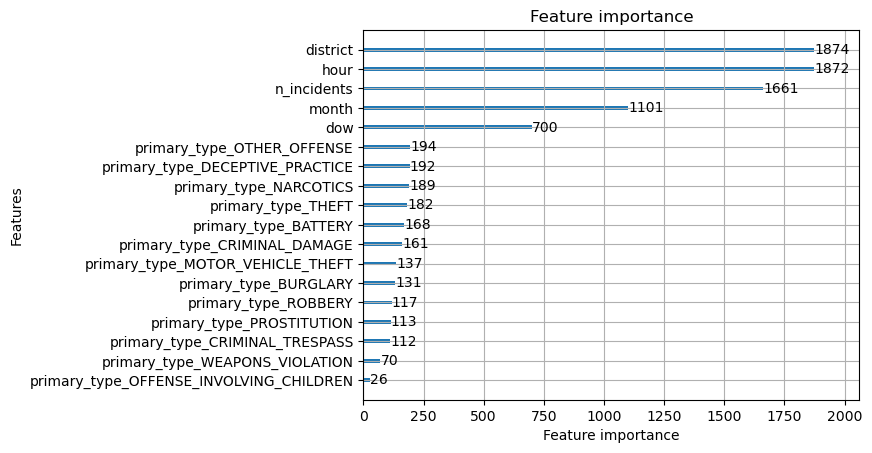

In [9]:
import matplotlib.pyplot as plt

lgb.plot_importance(model)
plt.show()